# Two-domain partial-observability controls

**TL;DR.** In both controlled pixel domains, two states can render exactly the same current frame
while hidden velocity changes the finite-horizon safe-action set. The single-frame observation
fiber is action-conflicted: every state has a safe audited action, but no action is safe for both.
A four-frame visible-position/direction history separates the constructed histories, and the
privileged state oracle separates them immediately. These are exact synthetic controls for
attribution, not learned-model results or long-horizon certificates.

## Assumptions and scope

- The cart and pendulum are repository-defined deterministic synthetic fixtures, not Gym tasks.
- Pixels expose position or angle plus nuisance but never velocity; the compared states share the
  same nuisance phase, so their current images are byte-for-byte equal.
- Safe-action margins use the frozen three-action grid and constant-action nominal rollout horizon
  from each config. They are not continuous-action viability kernels.
- `observation_feature_vector` is an evaluation oracle for visible kinematic factors, not a learned
  pixel encoder. `state_feature_vector` is privileged and nondeployable.

In [1]:
import dataclasses
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif (ROOT / "LatentSafety" / "src").exists():
    ROOT = ROOT / "LatentSafety"
if not (ROOT / "src" / "latent_safety").exists():
    raise RuntimeError(f"Could not locate repository root from {Path.cwd()}")
sys.path.insert(0, str(ROOT / "src"))

from latent_safety.learning import (
    CartState,
    PendulumState,
    action_safety_profile,
    load_config,
    observation_feature_vector,
    render_state,
    state_feature_vector,
)
from latent_safety.metrics.action import audit_exact_action_fibers

cart_config = load_config(
    ROOT / "configs" / "e1_world_models" / "torch_pilot.toml"
).data
pendulum_config = load_config(
    ROOT / "configs" / "e1_world_models" / "torch_pendulum_pilot.toml"
).data
display({
    "cart_task": cart_config.task,
    "pendulum_task": pendulum_config.task,
    "action_grid_cart": cart_config.actions,
    "action_grid_pendulum": pendulum_config.actions,
})

{'cart_task': 'controlled_cart_video',
 'pendulum_task': 'controlled_pendulum_video',
 'action_grid_cart': (-1.0, 0.0, 1.0),
 'action_grid_pendulum': (-1.0, 0.0, 1.0)}

## 1. Exact single-frame aliases with conflicting actions

In [2]:
fixtures = {
    "cart": {
        "config": cart_config,
        "states": (
            CartState(position=-0.25, velocity=-1.75, nuisance_phase=0.2),
            CartState(position=-0.25, velocity=2.45, nuisance_phase=0.2),
        ),
    },
    "pendulum": {
        "config": pendulum_config,
        "states": (
            PendulumState(angle=-0.60, angular_velocity=-0.50, nuisance_phase=0.2),
            PendulumState(angle=-0.60, angular_velocity=2.50, nuisance_phase=0.2),
        ),
    },
}

alias_rows = []
for task, fixture in fixtures.items():
    config = fixture["config"]
    left, right = fixture["states"]
    left_pixels = render_state(left, config)
    right_pixels = render_state(right, config)
    profiles = (action_safety_profile(left, config), action_safety_profile(right, config))
    h1_config = dataclasses.replace(config, history_length=1)
    h1_codes = (
        observation_feature_vector((left,), 0, h1_config),
        observation_feature_vector((right,), 0, h1_config),
    )
    action_audit = audit_exact_action_fibers(h1_codes, profiles)
    safe_sets = [
        tuple(action for action, margin in zip(config.actions, profile, strict=True) if margin >= 0)
        for profile in profiles
    ]
    assert left_pixels == right_pixels
    assert h1_codes[0] == h1_codes[1]
    assert all(safe_sets)
    assert not set(safe_sets[0]).intersection(safe_sets[1])
    assert action_audit.conflicting_fiber_count == 1
    assert state_feature_vector(left, config) != state_feature_vector(right, config)
    alias_rows.append({
        "task": task,
        "pixels_exactly_equal": left_pixels == right_pixels,
        "h1_observation_code": h1_codes[0],
        "safe_actions_state_0": safe_sets[0],
        "safe_actions_state_1": safe_sets[1],
        "required_common_action_violation": action_audit.worst_required_violation,
        "privileged_states_distinct": True,
    })

display(alias_rows)

[{'task': 'cart',
  'pixels_exactly_equal': True,
  'h1_observation_code': (-0.15625,),
  'safe_actions_state_0': (1.0,),
  'safe_actions_state_1': (-1.0, 0.0),
  'required_common_action_violation': 0.008515486720000465,
  'privileged_states_distinct': True},
 {'task': 'pendulum',
  'pixels_exactly_equal': True,
  'h1_observation_code': (-0.5646424733950355, 0.8253356149096782),
  'safe_actions_state_0': (1.0,),
  'safe_actions_state_1': (-1.0, 0.0),
  'required_common_action_violation': 0.01729452042067181,
  'privileged_states_distinct': True}]

## 2. Four-frame visible histories remove the constructed alias

The histories end at the same visible position/direction but arrive from opposite directions. H1
therefore sees equal codes; H4 sees different ordered visible-factor sequences. Distinct H4 fibers
permit different actions, so the exact finite audit no longer reports an alias-induced conflict.

In [3]:
cart_paths = (
    tuple(CartState(position, -1.75, 0.1 * index) for index, position in enumerate((-0.10, -0.15, -0.20, -0.25))),
    tuple(CartState(position, 2.45, 1.0 + 0.1 * index) for index, position in enumerate((-0.40, -0.35, -0.30, -0.25))),
)
pendulum_paths = (
    tuple(PendulumState(angle, -0.50, 0.1 * index) for index, angle in enumerate((-0.30, -0.40, -0.50, -0.60))),
    tuple(PendulumState(angle, 2.50, 1.0 + 0.1 * index) for index, angle in enumerate((-0.90, -0.80, -0.70, -0.60))),
)

history_rows = []
for task, paths, config in (
    ("cart", cart_paths, cart_config),
    ("pendulum", pendulum_paths, pendulum_config),
):
    h1 = dataclasses.replace(config, history_length=1)
    h4 = dataclasses.replace(config, history_length=4)
    h1_codes = tuple(observation_feature_vector(path, 3, h1) for path in paths)
    h4_codes = tuple(observation_feature_vector(path, 3, h4) for path in paths)
    profiles = tuple(action_safety_profile(path[-1], config) for path in paths)
    h1_audit = audit_exact_action_fibers(h1_codes, profiles)
    h4_audit = audit_exact_action_fibers(h4_codes, profiles)
    assert h1_codes[0] == h1_codes[1]
    assert h4_codes[0] != h4_codes[1]
    assert h1_audit.conflicting_fiber_count == 1
    assert h4_audit.conflicting_fiber_count == 0
    history_rows.append({
        "task": task,
        "h1_codes_equal": True,
        "h4_codes_equal": False,
        "h1_action_conflicts": h1_audit.conflicting_fiber_count,
        "h4_action_conflicts": h4_audit.conflicting_fiber_count,
        "h4_observation_dimension": len(h4_codes[0]),
    })

display(history_rows)

[{'task': 'cart',
  'h1_codes_equal': True,
  'h4_codes_equal': False,
  'h1_action_conflicts': 1,
  'h4_action_conflicts': 0,
  'h4_observation_dimension': 4},
 {'task': 'pendulum',
  'h1_codes_equal': True,
  'h4_codes_equal': False,
  'h1_action_conflicts': 1,
  'h4_action_conflicts': 0,
  'h4_observation_dimension': 8}]

## 3. Pixel-level visual audit

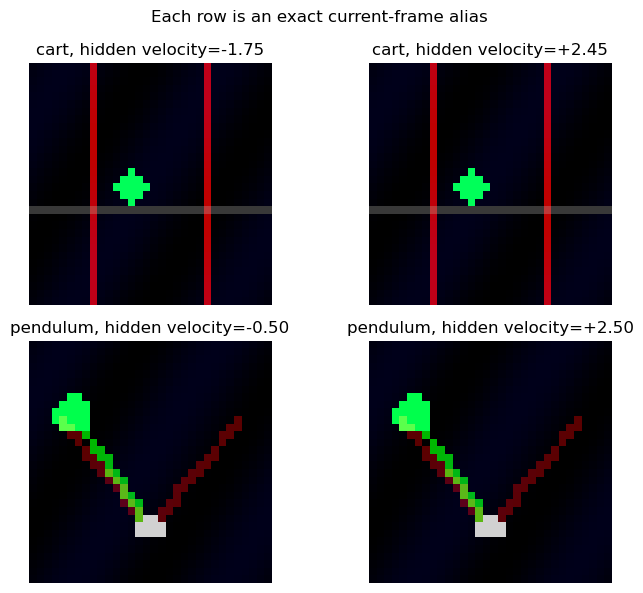

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(7.5, 6.0))
for row, (task, fixture) in enumerate(fixtures.items()):
    config = fixture["config"]
    for column, state in enumerate(fixture["states"]):
        pixels = np.asarray(render_state(state, config)).reshape(
            config.channels, config.image_size, config.image_size
        )
        axes[row, column].imshow(np.moveaxis(pixels, 0, -1), vmin=0.0, vmax=1.0)
        hidden_velocity = state.velocity if task == "cart" else state.angular_velocity
        axes[row, column].set_title(f"{task}, hidden velocity={hidden_velocity:+.2f}")
        axes[row, column].axis("off")
fig.suptitle("Each row is an exact current-frame alias")
fig.tight_layout()
plt.show()

for task, fixture in fixtures.items():
    config = fixture["config"]
    left, right = fixture["states"]
    assert render_state(left, config) == render_state(right, config)

## Takeaways

Both domains contain an exact, individually viable action conflict before learned compression. A
memoryless encoder cannot repair it because identical input pixels must receive the same
deterministic code. The visible H4 oracle separates the constructed histories, showing precisely
what extra information a history encoder may exploit; the state oracle is a full-information
control.

The result is a benchmark invariant, not evidence that a trained H4 model learns the distinction.
That claim still requires the paired GPU grids, observation-versus-encoder audits, matched utility,
and frozen validation/test analysis. It also remains relative to a finite constant-action profile,
not persistent closed-loop safety.